# Notebook 3 — Modélisation & Optimisation
**Projet IndabaX 2026 — Cameroun**

Prérequis : exécuter `01_EDA.ipynb` puis `02_FeatureEngineering.ipynb`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pickle, joblib, json as _json, os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from statsmodels.graphics.tsaplots import plot_acf
from scipy.stats import skew
import xgboost as xgb
import lightgbm as lgb

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

RANDOM_STATE = 42
TEST_YEAR    = 2025
HORIZONS     = [1, 7]
print('Imports OK.')


Imports OK.


## Chargement du contexte

In [2]:
df_feat      = pickle.load(open('../outputs/df_feat.pkl',           'rb'))
FEATURE_COLS = pickle.load(open('../outputs/feature_cols_list.pkl', 'rb'))
FEATURE_COLS = [c for c in FEATURE_COLS if c in df_feat.columns]
villes_ref   = [v for v in ['Maroua','Douala','Ngaoundere'] if v in df_feat['city'].values]
print(f'df_feat : {df_feat.shape} | Features : {len(FEATURE_COLS)}')


df_feat : (87240, 67) | Features : 38


## 1. Reconstruction du split

In [3]:
def make_split(df, horizon=1):
    target = f'target_t{horizon}'
    req    = FEATURE_COLS + [target, 'city', 'time', 'region', 'year']
    req    = [c for c in req if c in df.columns]
    dm    = df[req].dropna().reset_index(drop=True)
    train = dm[dm['year'] <= 2023].reset_index(drop=True)
    val   = dm[dm['year'] == 2024].reset_index(drop=True)
    test  = dm[dm['year'] == TEST_YEAR].reset_index(drop=True)
    return (train[FEATURE_COLS], train[target],
            val[FEATURE_COLS],   val[target],
            test[FEATURE_COLS],  test[target],
            train, val, test)

X_tr1, y_tr1, X_val1, y_val1, X_te1, y_te1, tr1, v1, te1 = make_split(df_feat, 1)


print('Split t+1 :')
print(f'  Train      : {len(X_tr1):>6,} | {tr1["time"].min().date()} -> {tr1["time"].max().date()}')
print(f'  Validation : {len(X_val1):>6,} | {v1["time"].min().date()} -> {v1["time"].max().date()}')
print(f'  Test       : {len(X_te1):>6,} | {te1["time"].min().date()} -> {te1["time"].max().date()}')
assert tr1['time'].max() < v1['time'].min()
assert v1['time'].max()  < te1['time'].min()
print('Anti-leakage : OK')


Split t+1 :
  Train      : 57,000 | 2020-02-06 -> 2023-12-31
  Validation : 14,640 | 2024-01-01 -> 2024-12-31
  Test       : 14,120 | 2025-01-01 -> 2025-12-19
Anti-leakage : OK


## 2. Fonctions de métriques
Le **Skill Score** mesure l'amélioration relative vs la persistance naïve.

In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def skill_score(y_true, y_pred, y_naive):
    mae_model = mean_absolute_error(y_true, y_pred)
    mae_naive = mean_absolute_error(y_true, y_naive)
    return round(1 - mae_model / (mae_naive + 1e-10), 4)

def evaluate(y_true, y_pred, y_naive, label=''):
    mae = mean_absolute_error(y_true, y_pred)
    rms = rmse(y_true, y_pred)
    ss  = skill_score(y_true, y_pred, y_naive)
    if label:
        print(f'{label:<35} MAE={mae:.4f}  RMSE={rms:.4f}  Skill={ss:.4f}')
    return {'Modele': label, 'MAE': round(mae,4), 'RMSE': round(rms,4), 'Skill': ss}

RESULTS = []


## 3. Baseline — Persistance

In [5]:
naive_val1  = X_val1['VRI_lag_1'].values;  naive_test1 = X_te1['VRI_lag_1'].values

for split, ytrue, ypred, naive, h in [
    ('Val',  y_val1, naive_val1,  naive_val1,  1),
    ('Test', y_te1,  naive_test1, naive_test1, 1)
]:
    r = evaluate(ytrue, ypred, naive, f'Baseline persistance t+{h} [{split}]')
    r['Split'] = split; r['Horizon'] = h; RESULTS.append(r)


Baseline persistance t+1 [Val]      MAE=0.0475  RMSE=0.1099  Skill=0.0000
Baseline persistance t+1 [Test]     MAE=0.0489  RMSE=0.1078  Skill=0.0000


## 4. Random Forest

In [6]:
print('Entraînement Random Forest...')
rf1 = RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=10,
                             max_features=0.6, n_jobs=-1, random_state=RANDOM_STATE)
rf1.fit(X_tr1, y_tr1)
pred_rf_val1  = rf1.predict(X_val1)
pred_rf_test1 = rf1.predict(X_te1)
for split, ytrue, ypred, naive in [
    ('Val',  y_val1, pred_rf_val1,  naive_val1),
    ('Test', y_te1,  pred_rf_test1, naive_test1),
]:
    r = evaluate(ytrue, ypred, naive, f'Random Forest t+1 [{split}]')
    r['Split'] = split; r['Horizon'] = 1; RESULTS.append(r)


Entraînement Random Forest...
Random Forest t+1 [Val]             MAE=0.0356  RMSE=0.0791  Skill=0.2503
Random Forest t+1 [Test]            MAE=0.0368  RMSE=0.0781  Skill=0.2467


## 5. XGBoost

In [7]:
print('Entraînement XGBoost...')
xgb_params = dict(n_estimators=2000, learning_rate=0.03, max_depth=6,
                  min_child_weight=5, subsample=0.8, colsample_bytree=0.7,
                  reg_alpha=0.1, reg_lambda=1.0, early_stopping_rounds=50,
                  eval_metric='mae', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)

xgb1 = xgb.XGBRegressor(**xgb_params)
xgb1.fit(X_tr1, y_tr1, eval_set=[(X_val1, y_val1)], verbose=False)
pred_xgb_val1  = xgb1.predict(X_val1)
pred_xgb_test1 = xgb1.predict(X_te1)
for split, ytrue, ypred, naive in [
    ('Val',  y_val1, pred_xgb_val1,  naive_val1),
    ('Test', y_te1,  pred_xgb_test1, naive_test1),
]:
    r = evaluate(ytrue, ypred, naive, f'XGBoost t+1 [{split}]')
    r['Split'] = split; r['Horizon'] = 1; RESULTS.append(r)


Entraînement XGBoost...
XGBoost t+1 [Val]                   MAE=0.0357  RMSE=0.0788  Skill=0.2477
XGBoost t+1 [Test]                  MAE=0.0362  RMSE=0.0775  Skill=0.2592


## 6. LightGBM

In [8]:
print('Entraînement LightGBM...')
lgb_params = dict(n_estimators=2000, learning_rate=0.03, num_leaves=63,
                  min_child_samples=20, subsample=0.8, colsample_bytree=0.7,
                  reg_alpha=0.1, reg_lambda=1.0, random_state=RANDOM_STATE,
                  n_jobs=-1, verbose=-1)
cb = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]

lgb1 = lgb.LGBMRegressor(**lgb_params)
lgb1.fit(X_tr1, y_tr1, eval_set=[(X_val1, y_val1)], callbacks=cb)
pred_lgb_val1  = lgb1.predict(X_val1)
pred_lgb_test1 = lgb1.predict(X_te1)
for split, ytrue, ypred, naive in [
    ('Val',  y_val1, pred_lgb_val1,  naive_val1),
    ('Test', y_te1,  pred_lgb_test1, naive_test1),
]:
    r = evaluate(ytrue, ypred, naive, f'LightGBM t+1 [{split}]')
    r['Split'] = split; r['Horizon'] = 1; RESULTS.append(r)


Entraînement LightGBM...
LightGBM t+1 [Val]                  MAE=0.0359  RMSE=0.0787  Skill=0.2439
LightGBM t+1 [Test]                 MAE=0.0367  RMSE=0.0778  Skill=0.2487


## 7. Optimisation des hyperparamètres — LightGBM
Grid search sur la validation uniquement. Le jeu de test n'est jamais touché pendant l'optimisation.

In [9]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    'num_leaves'       : [31, 63, 127],
    'learning_rate'    : [0.01, 0.03, 0.05],
    'min_child_samples': [10, 20],
}
best_mae, best_params = np.inf, {}

for params in ParameterGrid(param_grid):
    m = lgb.LGBMRegressor(n_estimators=1000, subsample=0.8, colsample_bytree=0.7,
                           reg_alpha=0.1, reg_lambda=1.0,
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **params)
    m.fit(X_tr1, y_tr1, eval_set=[(X_val1, y_val1)],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
    mae_v = mean_absolute_error(y_val1, m.predict(X_val1))
    if mae_v < best_mae:
        best_mae, best_params = mae_v, params

print(f'Meilleurs paramètres (validation) : {best_params}')
print(f'MAE validation : {best_mae:.4f}')

# Entraînement final avec les meilleurs paramètres
lgb1_opt = lgb.LGBMRegressor(n_estimators=2000, subsample=0.8, colsample_bytree=0.7,
                               reg_alpha=0.1, reg_lambda=1.0,
                               random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
                               **best_params)
lgb1_opt.fit(X_tr1, y_tr1, eval_set=[(X_val1, y_val1)],
             callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)])

pred_lgb_opt_val1  = lgb1_opt.predict(X_val1)
pred_lgb_opt_test1 = lgb1_opt.predict(X_te1)

for split, ytrue, ypred, naive in [
    ('Val',  y_val1, pred_lgb_opt_val1,  naive_val1),
    ('Test', y_te1,  pred_lgb_opt_test1, naive_test1),
]:
    r = evaluate(ytrue, ypred, naive, f'LightGBM optimisé t+1 [{split}]')
    r['Split'] = split; r['Horizon'] = 1; RESULTS.append(r)


Meilleurs paramètres (validation) : {'learning_rate': 0.03, 'min_child_samples': 20, 'num_leaves': 31}
MAE validation : 0.0358
LightGBM optimisé t+1 [Val]         MAE=0.0358  RMSE=0.0788  Skill=0.2461
LightGBM optimisé t+1 [Test]        MAE=0.0365  RMSE=0.0776  Skill=0.2539


## 8. Ensemble — moyenne pondérée XGBoost + LightGBM

In [10]:
# Poids inversement proportionnels à la MAE de validation
mae_xgb = mean_absolute_error(y_val1, pred_xgb_val1)
mae_lgb = mean_absolute_error(y_val1, pred_lgb_val1)
w_xgb   = (1/mae_xgb) / (1/mae_xgb + 1/mae_lgb)
w_lgb   = 1 - w_xgb
print(f'Poids XGBoost : {w_xgb:.3f} | Poids LightGBM : {w_lgb:.3f}')

pred_ens_val1  = np.clip(w_xgb * pred_xgb_val1  + w_lgb * pred_lgb_val1,  0, 1)
pred_ens_test1 = np.clip(w_xgb * pred_xgb_test1 + w_lgb * pred_lgb_test1, 0, 1)
for split, ytrue, ypred, naive in [
    ('Val',  y_val1, pred_ens_val1,  naive_val1),
    ('Test', y_te1,  pred_ens_test1, naive_test1),
]:
    r = evaluate(ytrue, ypred, naive, f'Ensemble XGB+LGBM t+1 [{split}]')
    r['Split'] = split; r['Horizon'] = 1; RESULTS.append(r)



Poids XGBoost : 0.501 | Poids LightGBM : 0.499
Ensemble XGB+LGBM t+1 [Val]         MAE=0.0357  RMSE=0.0787  Skill=0.2473
Ensemble XGB+LGBM t+1 [Test]        MAE=0.0364  RMSE=0.0775  Skill=0.2562


## 9. Tableau de bord comparatif

In [11]:
df_results = pd.DataFrame(RESULTS)
df_results = df_results[df_results['Split'] == 'Test'].drop(columns='Split')
df_results = df_results.sort_values(['Horizon','MAE']).reset_index(drop=True)

print('Performances sur le jeu de test (2025) :\n')
for h in sorted(df_results['Horizon'].unique()):
    print(f'  Horizon t+{h}')
    subset = df_results[df_results['Horizon'] == h][['Modele','MAE','RMSE','Skill']]
    print(subset.to_string(index=False)); print()


Performances sur le jeu de test (2025) :

  Horizon t+1
                         Modele    MAE   RMSE  Skill
             XGBoost t+1 [Test] 0.0362 0.0775 0.2592
   Ensemble XGB+LGBM t+1 [Test] 0.0364 0.0775 0.2562
   LightGBM optimisé t+1 [Test] 0.0365 0.0776 0.2539
            LightGBM t+1 [Test] 0.0367 0.0778 0.2487
       Random Forest t+1 [Test] 0.0368 0.0781 0.2467
Baseline persistance t+1 [Test] 0.0489 0.1078 0.0000



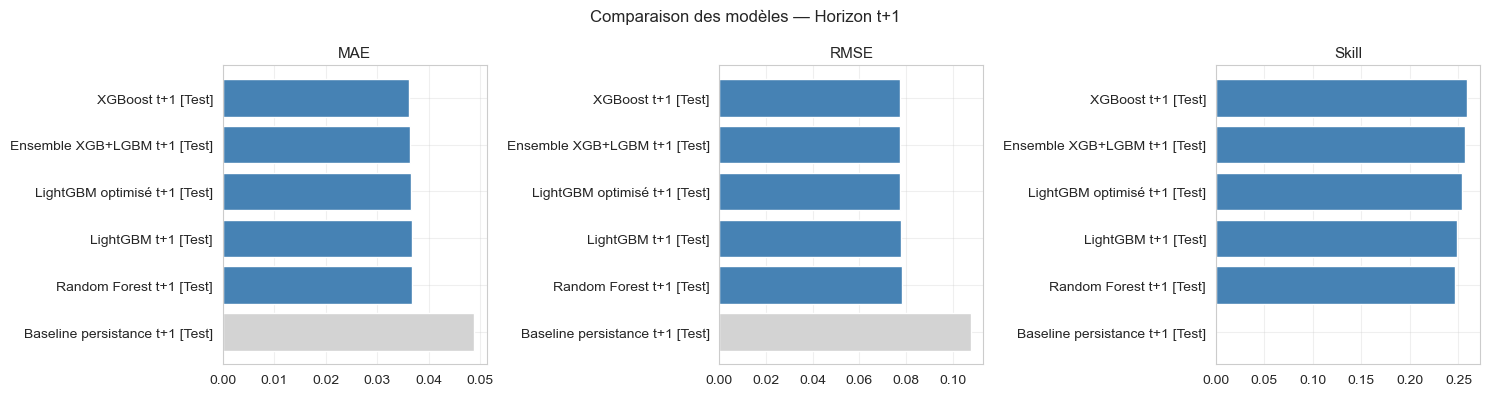

In [12]:
for h in [1]:
    sub = df_results[df_results['Horizon'] == h].sort_values('MAE')
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    colors = ['steelblue' if 'Baseline' not in m else 'lightgray' for m in sub['Modele']]
    for ax, metric in zip(axes, ['MAE','RMSE','Skill']):
        ax.barh(sub['Modele'], sub[metric], color=colors, edgecolor='white')
        ax.set_title(metric, fontsize=11); ax.invert_yaxis()
    fig.suptitle(f'Comparaison des modèles — Horizon t+{h}', fontsize=12)
    plt.tight_layout(); plt.show()


## 11. Analyse des résidus — LightGBM optimisé

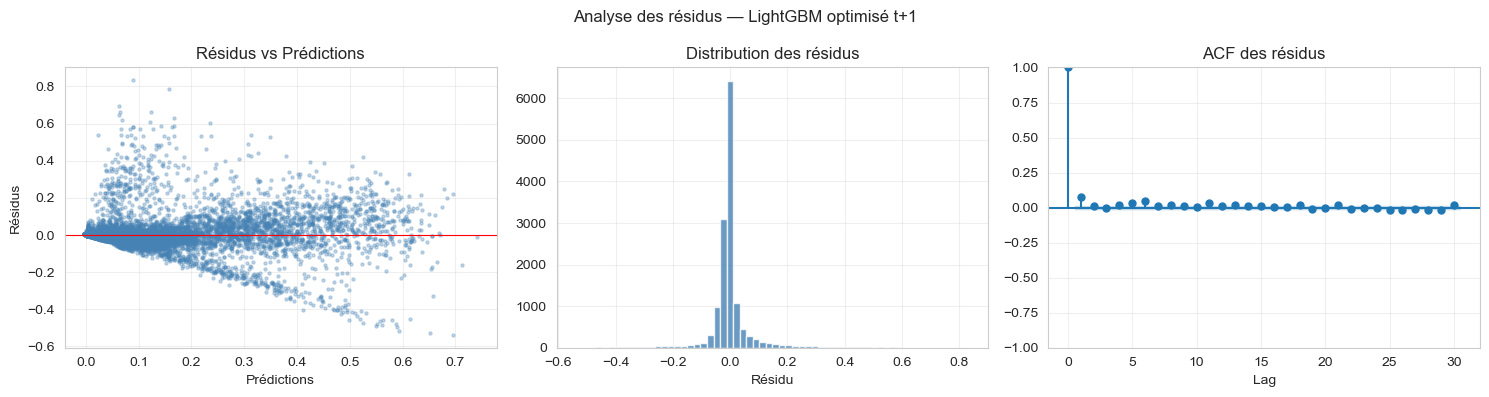

Résidu moyen : 0.00064  (proche de 0 = pas de biais)
Ecart-type   : 0.0776
Skewness     : 1.763


In [13]:
residus = y_te1.values - pred_lgb_opt_test1
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(pred_lgb_opt_test1, residus, alpha=0.3, s=5, color='steelblue')
axes[0].axhline(0, color='red', linewidth=0.8)
axes[0].set_xlabel('Prédictions'); axes[0].set_ylabel('Résidus')
axes[0].set_title('Résidus vs Prédictions')
axes[1].hist(residus, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution des résidus'); axes[1].set_xlabel('Résidu')
plot_acf(residus, lags=30, ax=axes[2], alpha=0.05)
axes[2].set_title('ACF des résidus'); axes[2].set_xlabel('Lag')
plt.suptitle('Analyse des résidus — LightGBM optimisé t+1', fontsize=12)
plt.tight_layout(); plt.show()
print(f'Résidu moyen : {residus.mean():.5f}  (proche de 0 = pas de biais)')
print(f'Ecart-type   : {residus.std():.4f}')
print(f'Skewness     : {skew(residus):.3f}')


## 12. Importance des variables

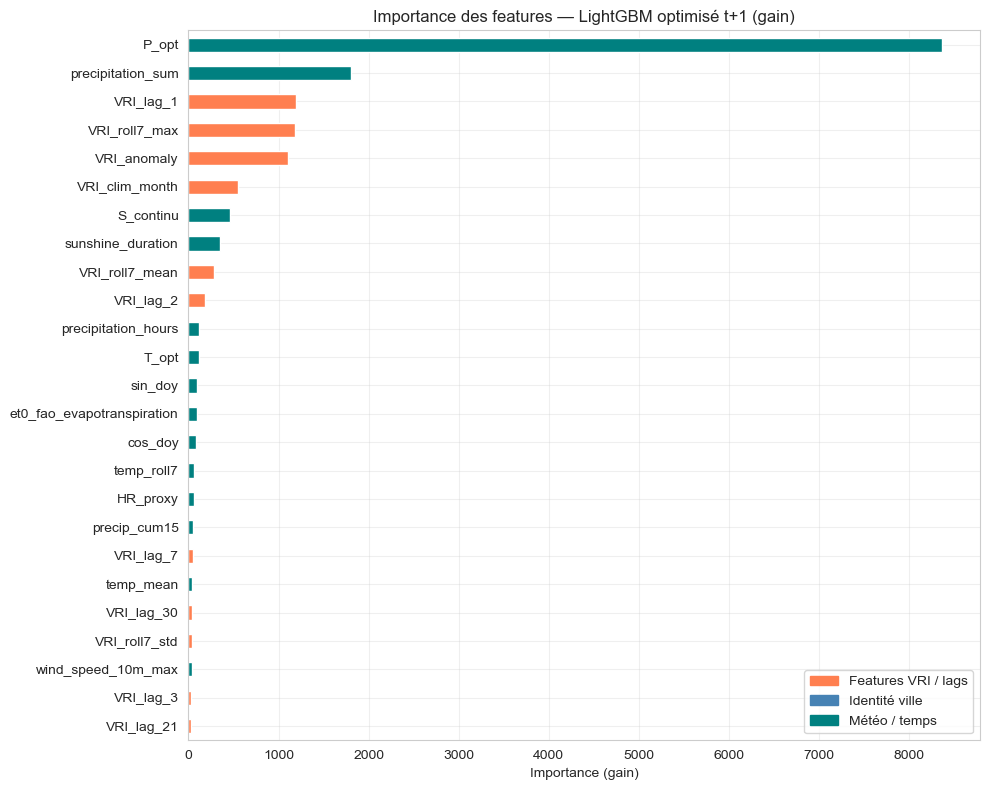

In [14]:
feat_imp = pd.Series(
    lgb1_opt.booster_.feature_importance(importance_type='gain'),
    index=FEATURE_COLS
).sort_values(ascending=True).tail(25)

fig, ax = plt.subplots(figsize=(10, 8))
colors_imp = ['coral'      if 'VRI' in f else
              'steelblue'  if f in ['city_enc','city_vri_mean','latitude','longitude'] else
              'teal' for f in feat_imp.index]
feat_imp.plot(kind='barh', ax=ax, color=colors_imp, edgecolor='white')
ax.set_title('Importance des features — LightGBM optimisé t+1 (gain)', fontsize=12)
ax.set_xlabel('Importance (gain)')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='coral',     label='Features VRI / lags'),
    Patch(color='steelblue', label='Identité ville'),
    Patch(color='teal',      label='Météo / temps'),
], loc='lower right')
plt.tight_layout(); plt.show()


## 13. Performances par ville et région

In [15]:
perf_ville = te1[['city','region']].copy()
perf_ville['y_true'] = y_te1.values
perf_ville['y_pred'] = pred_lgb_opt_test1

city_perf = (
    perf_ville.groupby(['city','region'])
    .apply(lambda g: pd.Series({
        'MAE'  : mean_absolute_error(g['y_true'], g['y_pred']),
        'RMSE' : rmse(g['y_true'], g['y_pred']),
        'N_obs': len(g)
    }), include_groups=False)
    .reset_index().sort_values('MAE')
)
print('Top 10 villes les mieux prédites :')
print(city_perf.head(10)[['city','region','MAE','RMSE']].to_string(index=False))
print()
print('Top 10 villes les moins bien prédites :')
print(city_perf.tail(10)[['city','region','MAE','RMSE']].to_string(index=False))
print()
print('MAE moyen par région :')
print(city_perf.groupby('region')['MAE'].mean().sort_values().round(4).to_string())


Top 10 villes les mieux prédites :
    city       region      MAE     RMSE
Kousseri Extreme-Nord 0.015444 0.052628
  Garoua         Nord 0.015802 0.047515
   Kumbo   Nord-Ouest 0.016603 0.031612
  Guider         Nord 0.018244 0.056824
 Touboro         Nord 0.021664 0.068602
    Poli         Nord 0.022370 0.066343
  Mbouda        Ouest 0.022593 0.045372
Meiganga     Adamaoua 0.024384 0.048526
  Maroua Extreme-Nord 0.024468 0.074681
  Yagoua Extreme-Nord 0.025677 0.078543

Top 10 villes les moins bien prédites :
      city    region      MAE     RMSE
      Buea Sud-Ouest 0.046746 0.084614
     Ambam       Sud 0.048674 0.087049
Sangmelima       Sud 0.049267 0.094464
Nkongsamba  Littoral 0.051421 0.085574
     Kumba Sud-Ouest 0.057927 0.099594
     Kribi       Sud 0.060075 0.100005
      Edea  Littoral 0.060756 0.107465
   Ebolowa       Sud 0.061786 0.114974
      Loum  Littoral 0.064895 0.107603
     Mamfe Sud-Ouest 0.067809 0.127488

MAE moyen par région :
region
Nord            0.0195
E

## 14. Prédictions vs réalité — villes de référence

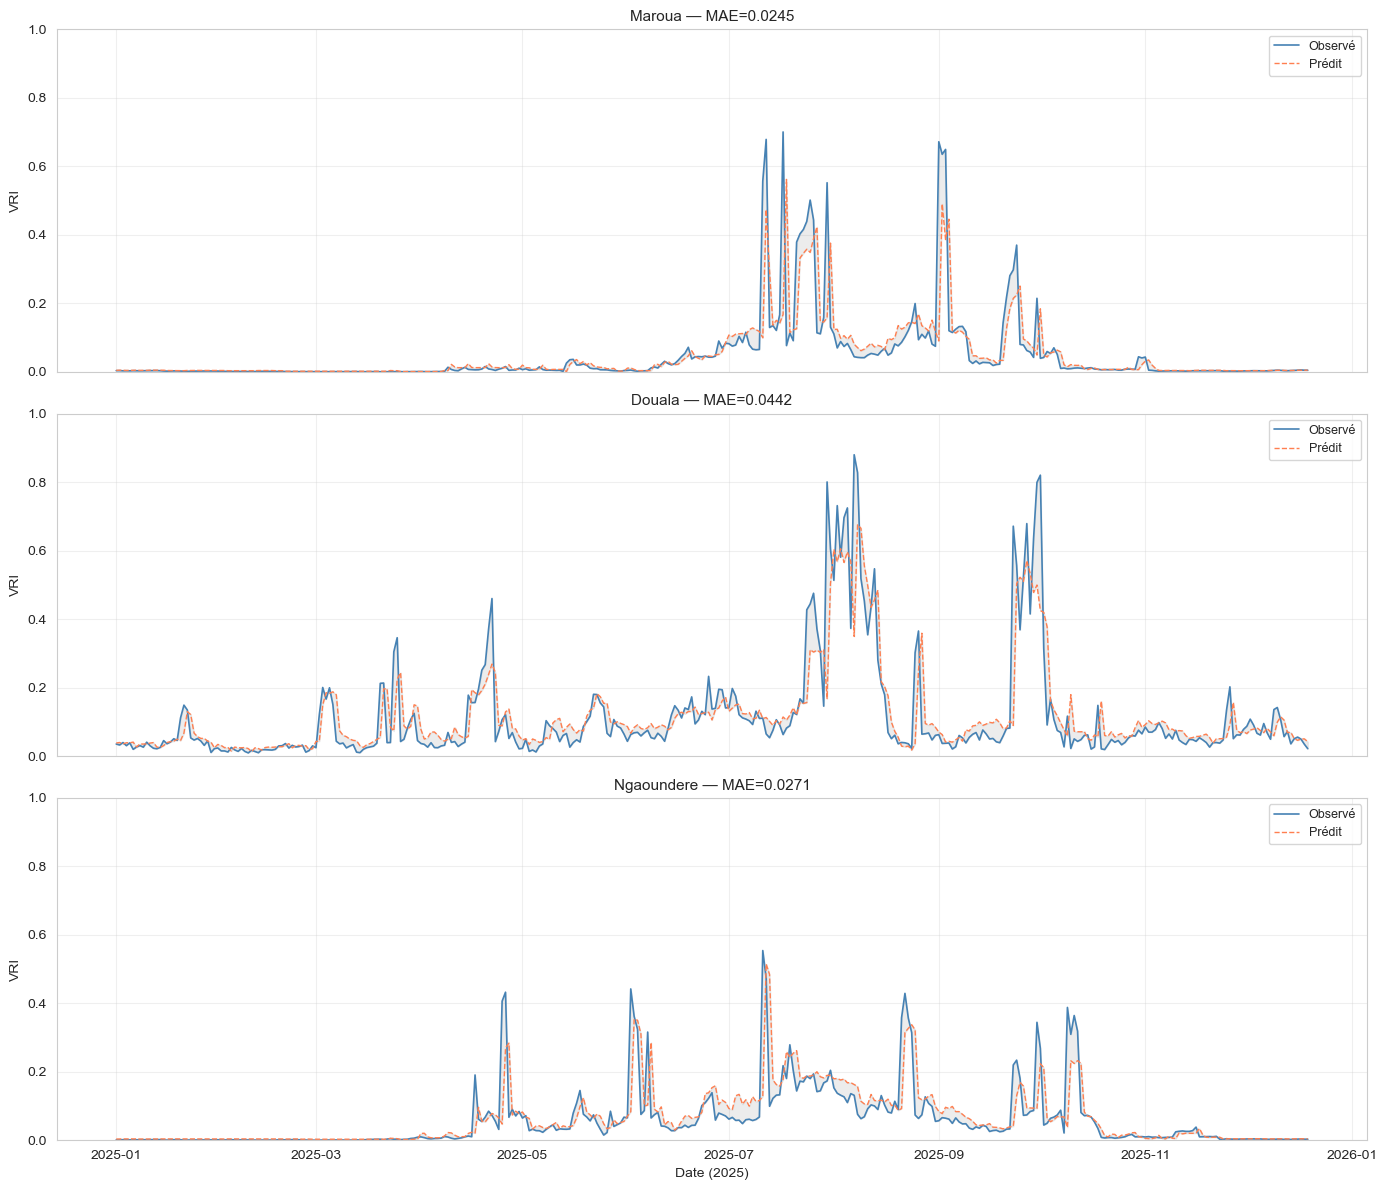

In [16]:
fig, axes = plt.subplots(len(villes_ref), 1,
                          figsize=(14, 4*len(villes_ref)), sharex=True)
if len(villes_ref) == 1: axes = [axes]
for ax, ville in zip(axes, villes_ref):
    mask  = te1['city'] == ville
    if mask.sum() == 0: continue
    dates = te1.loc[mask, 'time']
    y_v   = y_te1.values[mask.values]
    p_v   = pred_lgb_opt_test1[mask.values]
    mae_v = mean_absolute_error(y_v, p_v)
    ax.plot(dates, y_v, label='Observé',  color='steelblue', linewidth=1.2)
    ax.plot(dates, p_v, label='Prédit',   color='coral',     linewidth=1.0, linestyle='--')
    ax.fill_between(dates, y_v, p_v, alpha=0.15, color='gray')
    ax.set_title(f'{ville} — MAE={mae_v:.4f}', fontsize=11)
    ax.set_ylabel('VRI'); ax.set_ylim(0, 1); ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xlabel('Date (2025)')
plt.tight_layout(); plt.show()


## 15. Classification du risque vectoriel

Rapport de classification (classes de risque) :
              precision    recall  f1-score   support

      Faible       0.96      0.98      0.97     12701
       Moyen       0.67      0.63      0.65      1213
       Eleve       0.73      0.04      0.08       182

    accuracy                           0.94     14096
   macro avg       0.79      0.55      0.57     14096
weighted avg       0.94      0.94      0.93     14096



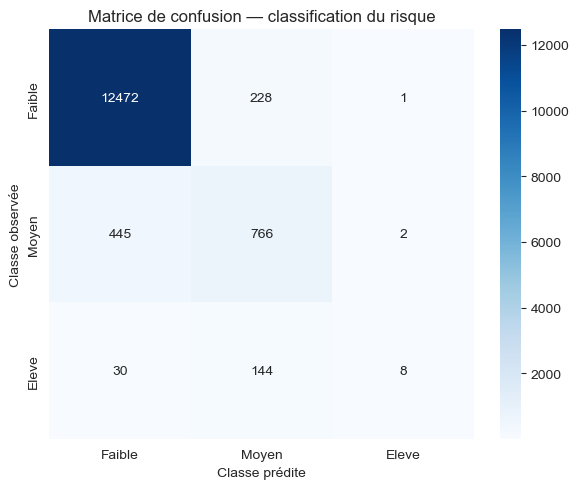

In [17]:
bins   = [-0.001, 0.33, 0.66, 1.001]
labels = ['Faible', 'Moyen', 'Eleve']

te1_out = te1[['time','city','region']].copy()
te1_out['VRI_observe'] = y_te1.values
te1_out['VRI_predit']  = pred_lgb_opt_test1

# Conversion str pour éviter TypeError pd.cut Categorical vs float NaN
te1_out['classe_observee'] = pd.cut(te1_out['VRI_observe'], bins=bins, labels=labels).astype(str)
te1_out['classe_predite']  = pd.cut(te1_out['VRI_predit'],  bins=bins, labels=labels).astype(str)
te1_out = te1_out[
    (te1_out['classe_observee'] != 'nan') &
    (te1_out['classe_predite']  != 'nan')
].reset_index(drop=True)

from sklearn.metrics import classification_report, confusion_matrix
print('Rapport de classification (classes de risque) :')
print(classification_report(te1_out['classe_observee'], te1_out['classe_predite'],
                             labels=labels, target_names=labels, zero_division=0))

cm = confusion_matrix(te1_out['classe_observee'], te1_out['classe_predite'], labels=labels)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=ax)
ax.set_xlabel('Classe prédite'); ax.set_ylabel('Classe observée')
ax.set_title('Matrice de confusion — classification du risque')
plt.tight_layout(); plt.show()


## 16. Prédiction mensuelle du VRI
Pour chaque ville, on agrège les prédictions journalières t+1 sur un mois donné.
- **VRI_predit_moyen** : niveau de risque moyen du mois
- **VRI_predit_max**   : pic de risque du mois
- **classe_risque_mensuel** : classe dominante (Faible / Moyen / Élevé)
- **jours_risque_eleve** : nombre de jours où le VRI prédit dépasse 0.66


## 17. Sauvegarde du meilleur modèle
Le modèle est sauvegardé avec **joblib** (recommandé pour sklearn/LightGBM) et **pickle** (format standard Python).
Les métadonnées JSON permettent la reproductibilité complète.


In [18]:
from datetime import datetime

os.makedirs('../models', exist_ok=True)

# ── joblib (recommandé — compression efficace)
joblib.dump(lgb1_opt,     '../models/lgb_optimise_t1.pkl')
joblib.dump(FEATURE_COLS, '../models/feature_cols.pkl')

# ── pickle (format standard Python)
with open('../models/lgb_optimise_t1_pickle.pkl', 'wb') as f:
    pickle.dump(lgb1_opt, f, protocol=4)
with open('../models/feature_cols_pickle.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f, protocol=4)

# ── Format natif LightGBM (interopérable)
lgb1_opt.booster_.save_model('../models/lgb_optimise_t1.txt')

# ── Métadonnées JSON
metadata = {
    'exported_at'   : datetime.now().isoformat(timespec='seconds'),
    'model_type'    : 'LightGBMRegressor',
    'target'        : 'VRI t+1 (Vector Risk Index, horizon 1 jour)',
    'train_period'  : f'{tr1["time"].min().date()} -> {tr1["time"].max().date()}',
    'val_period'    : f'{v1["time"].min().date()} -> {v1["time"].max().date()}',
    'test_period'   : f'{te1["time"].min().date()} -> {te1["time"].max().date()}',
    'n_train'       : int(len(X_tr1)),
    'n_val'         : int(len(X_val1)),
    'n_test'        : int(len(X_te1)),
    'n_features'    : len(FEATURE_COLS),
    'feature_names' : FEATURE_COLS,
    'best_params'   : best_params,
    'val_metrics'   : {
        'MAE'  : round(float(mean_absolute_error(y_val1, pred_lgb_opt_val1)),  4),
        'RMSE' : round(float(rmse(y_val1, pred_lgb_opt_val1)),                 4),
        'Skill': round(float(skill_score(y_val1, pred_lgb_opt_val1, naive_val1)), 4),
    },
    'test_metrics'  : {
        'MAE'  : round(float(mean_absolute_error(y_te1, pred_lgb_opt_test1)),  4),
        'RMSE' : round(float(rmse(y_te1, pred_lgb_opt_test1)),                 4),
        'Skill': round(float(skill_score(y_te1, pred_lgb_opt_test1, naive_test1)), 4),
    },
    'files': {
        'model_joblib'   : '../models/lgb_optimise_t1.pkl',
        'model_pickle'   : '../models/lgb_optimise_t1_pickle.pkl',
        'model_native'   : '../models/lgb_optimise_t1.txt',
        'feature_cols'   : '../models/feature_cols.pkl',
        'metadata'       : '../models/lgb_optimise_t1_metadata.json',
    }
}
with open('../models/lgb_optimise_t1_metadata.json', 'w', encoding='utf-8') as f:
    _json.dump(metadata, f, indent=2, ensure_ascii=False)

print('═' * 55)
print('  Modèle sauvegardé avec succès')
print('═' * 55)
print('  • ../models/lgb_optimise_t1.pkl         (joblib)')
print('  • ../models/lgb_optimise_t1_pickle.pkl  (pickle)')
print('  • ../models/lgb_optimise_t1.txt         (natif LightGBM)')
print('  • ../models/feature_cols.pkl')
print('  • ../models/lgb_optimise_t1_metadata.json')
print()
vm = metadata['val_metrics'];  tm = metadata['test_metrics']
print(f'  Val  → MAE={vm["MAE"]}  RMSE={vm["RMSE"]}  Skill={vm["Skill"]}')
print(f'  Test → MAE={tm["MAE"]}  RMSE={tm["RMSE"]}  Skill={tm["Skill"]}')


═══════════════════════════════════════════════════════
  Modèle sauvegardé avec succès
═══════════════════════════════════════════════════════
  • ../models/lgb_optimise_t1.pkl         (joblib)
  • ../models/lgb_optimise_t1_pickle.pkl  (pickle)
  • ../models/lgb_optimise_t1.txt         (natif LightGBM)
  • ../models/feature_cols.pkl
  • ../models/lgb_optimise_t1_metadata.json

  Val  → MAE=0.0358  RMSE=0.0788  Skill=0.2461
  Test → MAE=0.0365  RMSE=0.0776  Skill=0.2539


## 18. Vérification du rechargement

In [19]:
# Rechargement joblib
model_reloaded = joblib.load('../models/lgb_optimise_t1.pkl')
feats_reloaded = joblib.load('../models/feature_cols.pkl')

# Vérification reproductibilité
pred_check = model_reloaded.predict(X_te1)
assert np.allclose(pred_check, pred_lgb_opt_test1, atol=1e-6),     'ERREUR : prédictions divergentes après rechargement !'

print(f'Modèle rechargé : {type(model_reloaded).__name__}')
print(f'Features        : {len(feats_reloaded)} colonnes')
print('Reproductibilité : OK — prédictions identiques')

# Rechargement métadonnées
with open('../models/lgb_optimise_t1_metadata.json', encoding='utf-8') as f:
    meta = _json.load(f)
print(f'Exporté le : {meta["exported_at"]}')
print(f'Paramètres : {meta["best_params"]}')


Modèle rechargé : LGBMRegressor
Features        : 38 colonnes
Reproductibilité : OK — prédictions identiques
Exporté le : 2026-04-06T15:49:24
Paramètres : {'learning_rate': 0.03, 'min_child_samples': 20, 'num_leaves': 31}


---
# ✨ Améliorations v2 — Modélisation
> Ajouts progressifs au-dessus du code original.
> Chaque section est **autonome** : elle peut être retirée sans casser le reste.


## A. Modèle Dummy (Baseline statistique) + Ridge Regression
### Pourquoi un Dummy model ?
Avant tout entraînement sérieux, on mesure le **plancher de performance** :
un modèle qui prédit toujours la moyenne des cibles sur le train.
Si notre modèle ML ne fait pas mieux que ça, il est inutile.

### Pourquoi Ridge ?
La régression Ridge (L2) est un modèle **linéaire régularisé**.
Elle est rapide, interprétable, et sert de référence entre le Dummy et les modèles à base d'arbres.
Elle suppose une **relation linéaire** entre les features et la cible — souvent inexacte
pour les séries temporelles météo, mais utile comme borne inférieure raisonnable.


In [20]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import pickle

# ─────────────────────────────────────────────────────────────────
# Chargement des données scalées (si disponibles) ou raw
# ─────────────────────────────────────────────────────────────────
try:
    scaler = pickle.load(open('../outputs/scaler.pkl', 'rb'))
    features_to_scale = [
        c for c in FEATURE_COLS
        if c not in ['city_enc','sin_doy','cos_doy','sin_month','cos_month','month']
    ]
    def _scale(X):
        Xs = X.copy()
        Xs[features_to_scale] = scaler.transform(X[features_to_scale])
        return Xs
    X_tr1_sc, X_val1_sc, X_te1_sc = _scale(X_tr1), _scale(X_val1), _scale(X_te1)
    print('Données scalées chargées ✓')
except FileNotFoundError:
    # Fallback : StandardScaler ajusté ici
    features_to_scale = [
        c for c in FEATURE_COLS
        if c not in ['city_enc','sin_doy','cos_doy','sin_month','cos_month','month']
    ]
    scaler = StandardScaler().fit(X_tr1[features_to_scale])
    def _scale(X):
        Xs = X.copy()
        Xs[features_to_scale] = scaler.transform(X[features_to_scale])
        return Xs
    X_tr1_sc, X_val1_sc, X_te1_sc = _scale(X_tr1), _scale(X_val1), _scale(X_te1)
    print('Scaler créé à la volée ✓')

# ─── Dummy Regressor ─────────────────────────────────────────────
# strategy='mean' : prédit toujours la moyenne du train
# C'est le plancher absolu — tout modèle sérieux doit le battre
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_tr1, y_tr1)
pred_dummy_val1  = dummy.predict(X_val1)
pred_dummy_test1 = dummy.predict(X_te1)

for split, ytrue, ypred, naive in [
    ('Val',  y_val1, pred_dummy_val1,  naive_val1),
    ('Test', y_te1,  pred_dummy_test1, naive_test1),
]:
    r = evaluate(ytrue, ypred, naive, f'Dummy (mean) t+1 [{split}]')
    r['Split'] = split; r['Horizon'] = 1; RESULTS.append(r)

# ─── Ridge Regression ────────────────────────────────────────────
# alpha = force de régularisation L2 (défaut=1.0)
# On utilise les données *scalées* — Ridge est sensible à l'échelle
ridge = Ridge(alpha=1.0)
ridge.fit(X_tr1_sc, y_tr1)
pred_ridge_val1  = ridge.predict(X_val1_sc)
pred_ridge_test1 = ridge.predict(X_te1_sc)

for split, ytrue, ypred, naive in [
    ('Val',  y_val1, pred_ridge_val1,  naive_val1),
    ('Test', y_te1,  pred_ridge_test1, naive_test1),
]:
    r = evaluate(ytrue, ypred, naive, f'Ridge t+1 [{split}]')
    r['Split'] = split; r['Horizon'] = 1; RESULTS.append(r)

print('\n─── Interprétation ───────────────────────────────────────')
print('Dummy > Ridge > Persistance > RF > XGB/LGB : ordre attendu')
print('Un Skill Score négatif = le modèle est pire que la persistance')


Scaler créé à la volée ✓
Dummy (mean) t+1 [Val]              MAE=0.1002  RMSE=0.1437  Skill=-1.1095
Dummy (mean) t+1 [Test]             MAE=0.1037  RMSE=0.1520  Skill=-1.1215
Ridge t+1 [Val]                     MAE=0.0381  RMSE=0.0793  Skill=0.1986
Ridge t+1 [Test]                    MAE=0.0382  RMSE=0.0778  Skill=0.2197

─── Interprétation ───────────────────────────────────────
Dummy > Ridge > Persistance > RF > XGB/LGB : ordre attendu
Un Skill Score négatif = le modèle est pire que la persistance


## B. Pipeline complet horizon t+7 (prédiction à 7 jours)
### Logique de la transformation t+7
```
target_t7[i] = VRI[i + 7]   ← valeur future du VRI dans 7 jours
```
Cette cible est déjà construite dans le Feature Engineering (`target_t7`).
Le modèle apprend à prédire **ce que sera le VRI dans 7 jours**
à partir des informations disponibles aujourd'hui.

**Pourquoi c'est utile ?**
Un délai de 7 jours permet aux autorités sanitaires de :
- Anticiper les pics de risque vectoriel
- Planifier les campagnes de démoustication
- Alerter les populations à risque

**Différence avec t+1** : la prédiction à 7j est plus difficile
(plus d'incertitude) → on attend un MAE plus élevé et un Skill plus faible.
Cela est normal et attendu.


In [21]:
# ─────────────────────────────────────────────────────────────────
# Reconstruction du split t+7
# (identique au split t+1, seule la cible change)
# ─────────────────────────────────────────────────────────────────
X_tr7, y_tr7, X_val7, y_val7, X_te7, y_te7, tr7, v7, te7 = make_split(df_feat, 7)

# Baseline persistance t+7 : on utilise VRI_lag_7 comme prédiction naïve
# → "dans 7 jours, ce sera comme aujourd'hui"
naive_val7  = X_val7['VRI_lag_7'].values
naive_test7 = X_te7['VRI_lag_7'].values

print('Split t+7 :')
print(f'  Train  : {len(X_tr7):>6,} obs')
print(f'  Val    : {len(X_val7):>6,} obs')
print(f'  Test   : {len(X_te7):>6,} obs')

# ── Baseline persistance t+7 ─────────────────────────────────────
for split, ytrue, naive in [
    ('Val',  y_val7, naive_val7),
    ('Test', y_te7,  naive_test7),
]:
    r = evaluate(ytrue, naive, naive, f'Baseline persistance t+7 [{split}]')
    r['Split'] = split; r['Horizon'] = 7; RESULTS.append(r)

# ── Random Forest t+7 ────────────────────────────────────────────
print('\nEntraînement Random Forest t+7...')
rf7 = RandomForestRegressor(
    n_estimators=300, max_depth=10,
    min_samples_leaf=15,  # plus de régularisation pour horizon plus loin
    max_features=0.6, n_jobs=-1, random_state=RANDOM_STATE
)
rf7.fit(X_tr7, y_tr7)
pred_rf_val7  = rf7.predict(X_val7)
pred_rf_test7 = rf7.predict(X_te7)
for split, ytrue, ypred, naive in [
    ('Val',  y_val7, pred_rf_val7,  naive_val7),
    ('Test', y_te7,  pred_rf_test7, naive_test7),
]:
    r = evaluate(ytrue, ypred, naive, f'Random Forest t+7 [{split}]')
    r['Split'] = split; r['Horizon'] = 7; RESULTS.append(r)

# ── XGBoost t+7 ─────────────────────────────────────────────────
print('Entraînement XGBoost t+7...')
xgb7 = xgb.XGBRegressor(
    n_estimators=2000, learning_rate=0.03, max_depth=6,
    min_child_weight=8,   # plus strict → moins d'overfitting à 7j
    subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.2, reg_lambda=1.5,  # régularisation renforcée
    early_stopping_rounds=50, eval_metric='mae',
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
xgb7.fit(X_tr7, y_tr7, eval_set=[(X_val7, y_val7)], verbose=False)
pred_xgb_val7  = xgb7.predict(X_val7)
pred_xgb_test7 = xgb7.predict(X_te7)
for split, ytrue, ypred, naive in [
    ('Val',  y_val7, pred_xgb_val7,  naive_val7),
    ('Test', y_te7,  pred_xgb_test7, naive_test7),
]:
    r = evaluate(ytrue, ypred, naive, f'XGBoost t+7 [{split}]')
    r['Split'] = split; r['Horizon'] = 7; RESULTS.append(r)

# ── LightGBM t+7 optimisé ────────────────────────────────────────
print('Entraînement LightGBM t+7...')
import lightgbm as lgb
lgb7 = lgb.LGBMRegressor(
    n_estimators=2000, learning_rate=0.03, num_leaves=63,
    min_child_samples=30, subsample=0.8, colsample_bytree=0.7,
    reg_alpha=0.2, reg_lambda=1.5,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
cb7 = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
lgb7.fit(X_tr7, y_tr7, eval_set=[(X_val7, y_val7)], callbacks=cb7)
pred_lgb_val7  = lgb7.predict(X_val7)
pred_lgb_test7 = lgb7.predict(X_te7)
for split, ytrue, ypred, naive in [
    ('Val',  y_val7, pred_lgb_val7,  naive_val7),
    ('Test', y_te7,  pred_lgb_test7, naive_test7),
]:
    r = evaluate(ytrue, ypred, naive, f'LightGBM t+7 [{split}]')
    r['Split'] = split; r['Horizon'] = 7; RESULTS.append(r)


Split t+7 :
  Train  : 57,000 obs
  Val    : 14,640 obs
  Test   : 13,880 obs
Baseline persistance t+7 [Val]      MAE=0.0884  RMSE=0.1661  Skill=0.0000
Baseline persistance t+7 [Test]     MAE=0.0971  RMSE=0.1737  Skill=0.0000

Entraînement Random Forest t+7...
Random Forest t+7 [Val]             MAE=0.0688  RMSE=0.1135  Skill=0.2213
Random Forest t+7 [Test]            MAE=0.0716  RMSE=0.1186  Skill=0.2629
Entraînement XGBoost t+7...
XGBoost t+7 [Val]                   MAE=0.0690  RMSE=0.1135  Skill=0.2188
XGBoost t+7 [Test]                  MAE=0.0719  RMSE=0.1182  Skill=0.2603
Entraînement LightGBM t+7...
LightGBM t+7 [Val]                  MAE=0.0714  RMSE=0.1143  Skill=0.1918
LightGBM t+7 [Test]                 MAE=0.0738  RMSE=0.1197  Skill=0.2408


## C. Validation croisée temporelle (TimeSeriesSplit)
### Pourquoi pas un KFold classique ?
Un `KFold` mélange les données aléatoirement → une observation de 2025
peut se retrouver dans le **train** d'un fold, et une de 2020 dans le **test**.
C'est du **data leakage temporel** : le modèle "voit le futur".

`TimeSeriesSplit` garantit que le train précède toujours le test dans le temps.
C'est la seule forme de CV correcte pour les séries temporelles.

```
Fold 1 : Train [─────]  Test [─]
Fold 2 : Train [──────] Test [─]
Fold 3 : Train [───────]Test [─]
         ↑ grandissant       ↑ toujours dans le futur
```


In [22]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# ─────────────────────────────────────────────────────────────────
# TimeSeriesSplit : 5 folds, train initial = 60% des données
# On combine train+val pour la CV (le test reste intouché)
# ─────────────────────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)

# Données train+val combinées (jamais de test !)
X_trainval = pd.concat([X_tr1, X_val1]).reset_index(drop=True)
y_trainval = pd.concat([y_tr1, y_val1]).reset_index(drop=True)

print('Validation croisée temporelle (5 folds) sur LightGBM t+1...')
print(f'N train+val : {len(X_trainval):,} observations')
print()

cv_scores = []
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_trainval), 1):
    X_cv_tr, X_cv_val = X_trainval.iloc[train_idx], X_trainval.iloc[val_idx]
    y_cv_tr, y_cv_val = y_trainval.iloc[train_idx], y_trainval.iloc[val_idx]

    m = lgb.LGBMRegressor(
        n_estimators=500, learning_rate=0.05, num_leaves=63,
        min_child_samples=20, subsample=0.8, colsample_bytree=0.7,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
    m.fit(X_cv_tr, y_cv_tr,
          eval_set=[(X_cv_val, y_cv_val)],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])

    from sklearn.metrics import mean_absolute_error
    mae_fold = mean_absolute_error(y_cv_val, m.predict(X_cv_val))
    cv_scores.append(mae_fold)
    print(f'  Fold {fold} | Train: {len(X_cv_tr):>6,} | Val: {len(X_cv_val):>5,} | MAE = {mae_fold:.4f}')

print()
print(f'MAE CV moyenne  : {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')
print(f'MAE Test finale : {mean_absolute_error(y_te1, pred_lgb_opt_test1):.4f}')
print()
print('Interprétation : si MAE CV ≈ MAE Test → bonne généralisation')
print('Si MAE CV << MAE Test → possible overfitting sur val')


Validation croisée temporelle (5 folds) sur LightGBM t+1...
N train+val : 71,640 observations

  Fold 1 | Train: 11,940 | Val: 11,940 | MAE = 0.0441
  Fold 2 | Train: 23,880 | Val: 11,940 | MAE = 0.0488
  Fold 3 | Train: 35,820 | Val: 11,940 | MAE = 0.0331
  Fold 4 | Train: 47,760 | Val: 11,940 | MAE = 0.0348
  Fold 5 | Train: 59,700 | Val: 11,940 | MAE = 0.0363

MAE CV moyenne  : 0.0394 ± 0.0060
MAE Test finale : 0.0365

Interprétation : si MAE CV ≈ MAE Test → bonne généralisation
Si MAE CV << MAE Test → possible overfitting sur val


## D. Courbes ROC et AUC — Détection risque élevé (VRI > 0.66)
### Du problème de régression au problème de classification
On transforme la prédiction continue en **classification binaire** :
- Classe 1 : **Risque élevé** (VRI ≥ 0.66)
- Classe 0 : **Risque non-élevé** (VRI < 0.66)

La **courbe ROC** trace le taux de vrais positifs (sensibilité)
en fonction du taux de faux positifs pour différents seuils.
L'**AUC** (aire sous la courbe) mesure la capacité du modèle
à discriminer les deux classes : AUC=1 → parfait, AUC=0.5 → aléatoire.

En santé publique, on préfère **maximiser la sensibilité** (ne pas manquer
un vrai épisode à risque) au prix de quelques fausses alarmes.


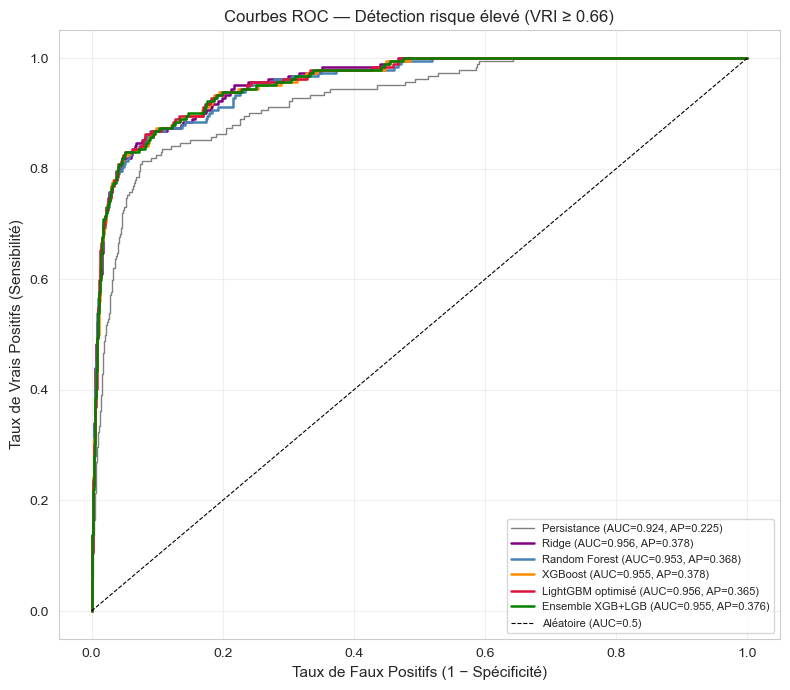


── AUC et Average Precision (résumé) ──────────────────────
  Persistance               AUC=0.9239  AP=0.2245
  Ridge                     AUC=0.9561  AP=0.3784
  Random Forest             AUC=0.9531  AP=0.3679
  XGBoost                   AUC=0.9550  AP=0.3779
  LightGBM optimisé         AUC=0.9559  AP=0.3647
  Ensemble XGB+LGB          AUC=0.9552  AP=0.3763


In [23]:
from sklearn.metrics import roc_curve, roc_auc_score, average_precision_score
import matplotlib.pyplot as plt

SEUIL_ELEVE = 0.66

# Binarisation de la cible
y_te1_bin = (y_te1.values >= SEUIL_ELEVE).astype(int)

# Dictionnaire modèle → scores (probabilité continue = prédiction VRI)
models_scores = {
    'Persistance'       : naive_test1,
    'Ridge'             : np.clip(pred_ridge_test1, 0, 1),
    'Random Forest'     : pred_rf_test1,
    'XGBoost'           : pred_xgb_test1,
    'LightGBM optimisé' : pred_lgb_opt_test1,
    'Ensemble XGB+LGB'  : pred_ens_test1,
}

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['gray','purple','steelblue','darkorange','crimson','green']

for (name, scores), color in zip(models_scores.items(), colors):
    fpr, tpr, _ = roc_curve(y_te1_bin, scores)
    auc = roc_auc_score(y_te1_bin, scores)
    ap  = average_precision_score(y_te1_bin, scores)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f}, AP={ap:.3f})',
            color=color, linewidth=1.8 if name != 'Persistance' else 1)

ax.plot([0,1],[0,1], 'k--', linewidth=0.8, label='Aléatoire (AUC=0.5)')
ax.set_xlabel('Taux de Faux Positifs (1 − Spécificité)', fontsize=11)
ax.set_ylabel('Taux de Vrais Positifs (Sensibilité)', fontsize=11)
ax.set_title('Courbes ROC — Détection risque élevé (VRI ≥ 0.66)', fontsize=12)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

print('\n── AUC et Average Precision (résumé) ──────────────────────')
for name, scores in models_scores.items():
    auc = roc_auc_score(y_te1_bin, scores)
    ap  = average_precision_score(y_te1_bin, scores)
    print(f'  {name:<25} AUC={auc:.4f}  AP={ap:.4f}')


## E. Tableau comparatif final — tous modèles, tous horizons
Ce tableau consolide **toutes les performances** dans un même espace.
Il facilite le choix du modèle final selon le critère opérationnel :
- **MAE** : erreur absolue moyenne (unité = VRI points)
- **RMSE** : pénalise davantage les grosses erreurs
- **Skill** : amélioration relative vs persistance naïve (>0 = utile)


══════════════════════════════════════════════════════════════════════
  TABLEAU DE BORD FINAL — Jeu de test 2025
══════════════════════════════════════════════════════════════════════

  ── Horizon t+1 ──────────────────────────────────────────
                         Modele    MAE   RMSE   Skill
             XGBoost t+1 [Test] 0.0362 0.0775  0.2592
   Ensemble XGB+LGBM t+1 [Test] 0.0364 0.0775  0.2562
   LightGBM optimisé t+1 [Test] 0.0365 0.0776  0.2539
            LightGBM t+1 [Test] 0.0367 0.0778  0.2487
       Random Forest t+1 [Test] 0.0368 0.0781  0.2467
               Ridge t+1 [Test] 0.0382 0.0778  0.2197
Baseline persistance t+1 [Test] 0.0489 0.1078  0.0000
        Dummy (mean) t+1 [Test] 0.1037 0.1520 -1.1215

  ── Horizon t+7 ──────────────────────────────────────────
                         Modele    MAE   RMSE  Skill
       Random Forest t+7 [Test] 0.0716 0.1186 0.2629
             XGBoost t+7 [Test] 0.0719 0.1182 0.2603
            LightGBM t+7 [Test] 0.0738 0.1197 0.

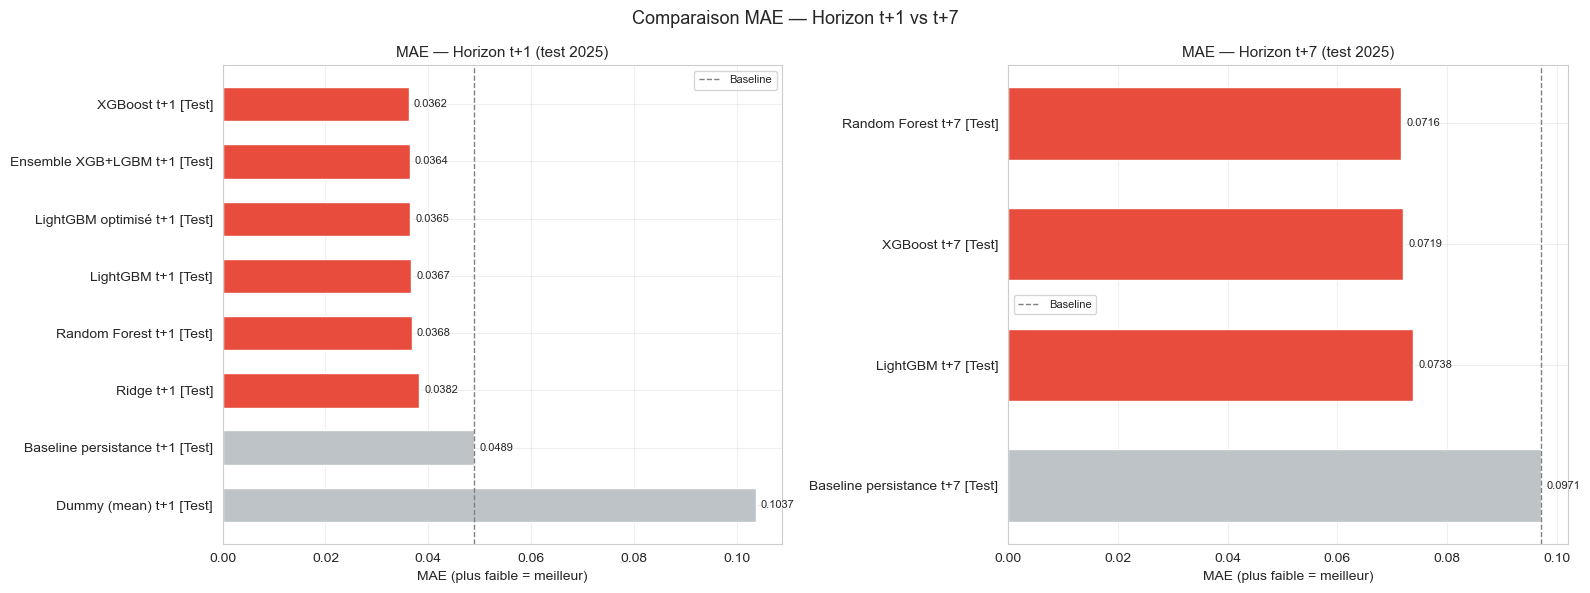

In [24]:
import pandas as pd

df_results_all = pd.DataFrame(RESULTS)
df_test_all    = (df_results_all[df_results_all['Split'] == 'Test']
                  .drop(columns='Split')
                  .sort_values(['Horizon','MAE'])
                  .reset_index(drop=True))

print('═' * 70)
print('  TABLEAU DE BORD FINAL — Jeu de test 2025')
print('═' * 70)
for h in sorted(df_test_all['Horizon'].unique()):
    print(f'\n  ── Horizon t+{h} ──────────────────────────────────────────')
    sub = df_test_all[df_test_all['Horizon'] == h][['Modele','MAE','RMSE','Skill']]
    print(sub.to_string(index=False))

# ── Graphique comparatif multi-horizons ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, h in zip(axes, [1, 7]):
    sub = df_test_all[df_test_all['Horizon'] == h].sort_values('MAE')
    colors = ['#e74c3c' if 'Baseline' not in m and 'Dummy' not in m else '#bdc3c7'
              for m in sub['Modele']]
    bars = ax.barh(sub['Modele'], sub['MAE'], color=colors, edgecolor='white', height=0.6)
    # Ajouter les valeurs sur les barres
    for bar, val in zip(bars, sub['MAE']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.set_title(f'MAE — Horizon t+{h} (test 2025)', fontsize=11)
    ax.set_xlabel('MAE (plus faible = meilleur)')
    ax.invert_yaxis()
    ax.axvline(sub[sub['Modele'].str.contains('Baseline')]['MAE'].values[0]
               if sub['Modele'].str.contains('Baseline').any() else 0,
               color='gray', linestyle='--', linewidth=1, label='Baseline')
    ax.legend(fontsize=8)

plt.suptitle('Comparaison MAE — Horizon t+1 vs t+7', fontsize=13)
plt.tight_layout()
plt.show()


## F. Pipeline ML réutilisable
Un pipeline encapsule **preprocessing + modèle** dans un seul objet.
Avantages :
- Une seule ligne pour entraîner, prédire, sauvegarder
- Pas de fuite du scaler (il est ajusté à l'intérieur du pipeline)
- Compatible avec `cross_val_score`, `GridSearchCV`, `joblib.dump`


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib

# ─────────────────────────────────────────────────────────────────
# Pipeline Ridge (modèle linéaire — nécessite scaling)
# ─────────────────────────────────────────────────────────────────
from sklearn.linear_model import Ridge
from sklearn.compose import ColumnTransformer

# On scale uniquement les colonnes continues
feats_to_scale = [
    c for c in FEATURE_COLS
    if c not in ['city_enc','sin_doy','cos_doy','sin_month','cos_month','month']
]
feats_pass_through = [c for c in FEATURE_COLS if c not in feats_to_scale]

preprocessor = ColumnTransformer(transformers=[
    ('scale', StandardScaler(), feats_to_scale),
    ('pass',  'passthrough',    feats_pass_through),
])

pipe_ridge = Pipeline(steps=[
    ('prep',  preprocessor),
    ('model', Ridge(alpha=1.0)),
])

pipe_ridge.fit(X_tr1, y_tr1)
pred_pipe_test = pipe_ridge.predict(X_te1)

from sklearn.metrics import mean_absolute_error
print(f'Pipeline Ridge — MAE test : {mean_absolute_error(y_te1, pred_pipe_test):.4f}')

# Sauvegarde du pipeline complet
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(pipe_ridge, '../models/pipeline_ridge_t1.pkl')
print('Pipeline sauvegardé : ../models/pipeline_ridge_t1.pkl')

# ─────────────────────────────────────────────────────────────────
# Fonction de prédiction production-ready
# ─────────────────────────────────────────────────────────────────
def predict_vri(
    model,
    X: pd.DataFrame,
    feature_cols: list,
    clip: bool = True
) -> np.ndarray:
    """
    Wrapper de prédiction production-ready.

    Paramètres
    ----------
    model        : modèle entraîné (sklearn, XGBoost, LightGBM ou Pipeline)
    X            : DataFrame contenant les features
    feature_cols : liste des colonnes attendues par le modèle
    clip         : si True, les prédictions sont bornées dans [0, 1]

    Retourne
    --------
    np.ndarray de prédictions VRI
    """
    missing = set(feature_cols) - set(X.columns)
    if missing:
        raise ValueError(f'Features manquantes : {missing}')

    preds = model.predict(X[feature_cols])
    return np.clip(preds, 0, 1) if clip else preds


# Test de la fonction
preds_demo = predict_vri(lgb1_opt, X_te1, FEATURE_COLS)
print(f'\nFonction predict_vri OK — {len(preds_demo)} prédictions')
print(f'Range prédictions : [{preds_demo.min():.4f}, {preds_demo.max():.4f}]')


Pipeline Ridge — MAE test : 0.0382
Pipeline sauvegardé : ../models/pipeline_ridge_t1.pkl

Fonction predict_vri OK — 14120 prédictions
Range prédictions : [0.0000, 0.7408]


## G. Pistes d'amélioration — MLOps & Déploiement
Ce notebook constitue une base solide. Voici les prochaines étapes recommandées :

### Court terme (1–2 semaines)
- **Optuna** : remplacer le `ParameterGrid` manuel par une optimisation bayésienne
  (`pip install optuna`) — 10× plus efficace pour explorer l'espace des hyperparamètres
- **SHAP** : expliquer les prédictions individuelles avec `shap.TreeExplainer` —
  critique pour la confiance des utilisateurs de santé publique

### Moyen terme (1 mois)
- **MLflow** : tracer toutes les expériences (paramètres, métriques, artefacts)
  ```python
  import mlflow
  mlflow.lightgbm.autolog()  # une seule ligne
  ```
- **API FastAPI** : exposer le modèle via une API REST :
  ```
  POST /predict  {city, date, features...} → {VRI_t1, VRI_t7, risk_class}
  ```
- **Monitoring** : détecter la dérive du modèle avec `evidently` ou `nannyml`

### Long terme (3+ mois)
- **Retrain automatique** : pipeline CI/CD (GitHub Actions + DVC)
- **Modèles spatiaux** : intégrer les corrélations entre villes voisines
  (LSTM spatial, GNN) pour améliorer les prédictions en zones frontalières
- **Données temps réel** : coupler avec l'API Open-Meteo pour des prédictions
  alimentées par les prévisions météo (NWP) sur 7 jours
